Librerías cargadas exitosamente.
Cargando datasets...

--- DATASET LIMPIO Y PROCESADO (Primeras 5 filas) ---
   Year  CO2_Mt  CO2_per_capita  Renewables_pct  Energy_per_capita  population
0  1990  56.857        1.752678          72.609        7782.999442  32440064.0
1  1991  56.609        1.710326          69.772        7830.264043  33098373.0
2  1992  61.341        1.816942          61.783        7953.242260  33760571.0
3  1993  63.260        1.836739          67.749        8483.549734  34441479.0
4  1994  66.982        1.906830          72.189        9006.927013  35127408.0

Base limpia guardada como 'datos_limpios_colombia_1990_2021.xlsx'. Descargando...


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>


--- ESTADÍSTICA DESCRIPTIVA COMPLETA (COLOMBIA 1990-2021) ---
         Variable   Media  Mediana  Moda*  Desv. Est.  Asimetría (Skew)  Mínimo   Máximo
           CO2_Mt   70.98    65.33   57.0       15.10              0.72   54.32   103.73
   CO2_per_capita    1.68     1.72    2.0        0.21             -0.17    1.31     2.03
   Renewables_pct   72.86    72.65   69.0        6.24             -0.07   61.78    83.89
Energy_per_capita 9372.31  9144.85 9041.0     1276.98              0.46 7783.00 11652.96


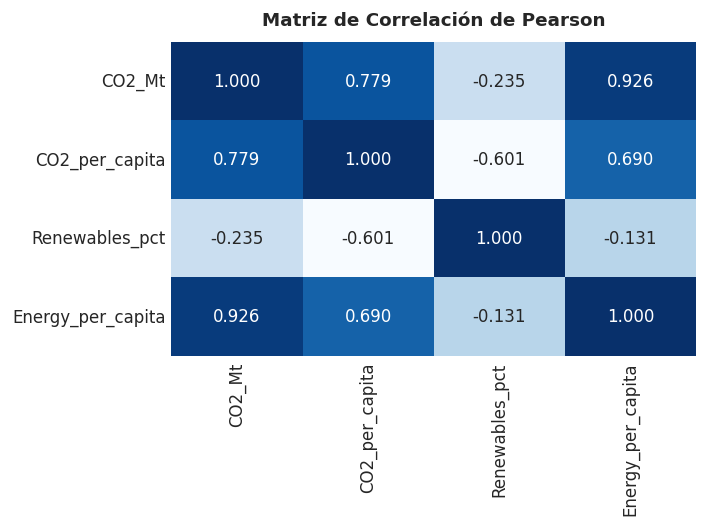

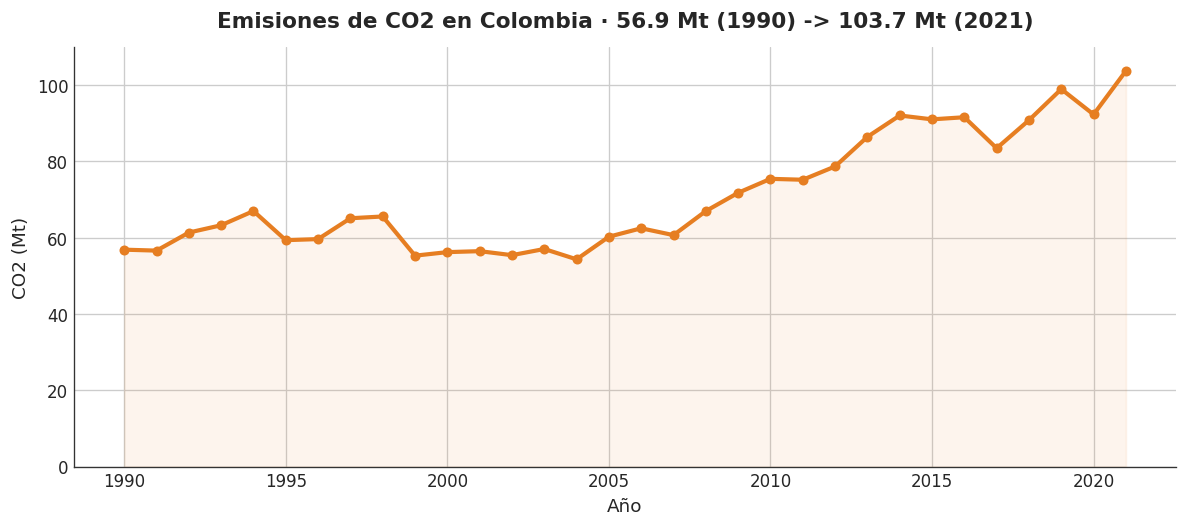

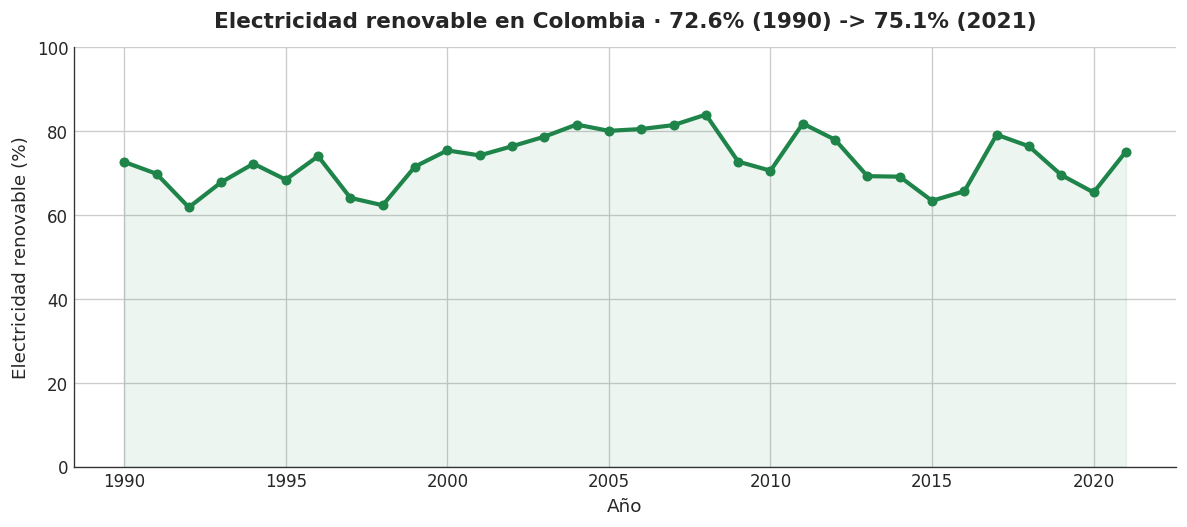

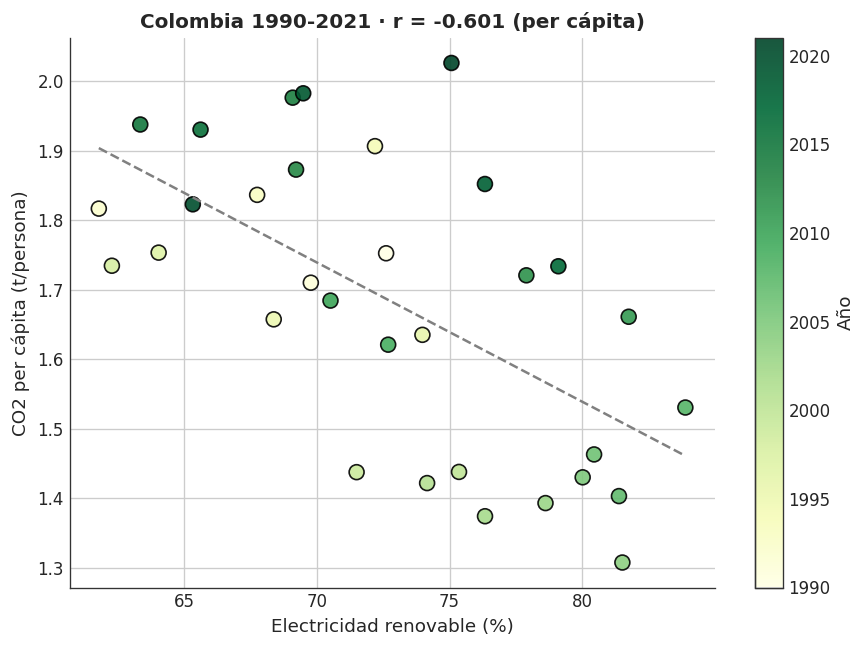

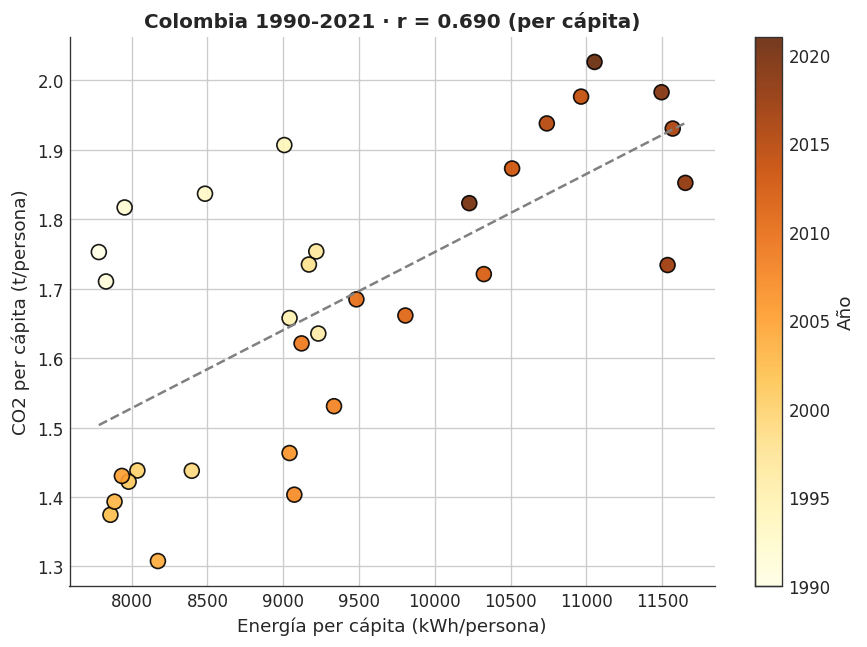


--- EVALUACIÓN COMPLETA DE LOS 6 MODELOS ---
           Modelo  R² (LOOCV)     RMSE      MAE
        KNN (k=6)    0.728250 0.106804 0.076128
       Ridge (L2)    0.692336 0.113643 0.092937
 Regresion Lineal    0.691601 0.113779 0.092860
       Lasso (L1)    0.687603 0.114514 0.093559
    Random Forest    0.573671 0.133775 0.090103
Arbol de Decision    0.419373 0.156118 0.113676


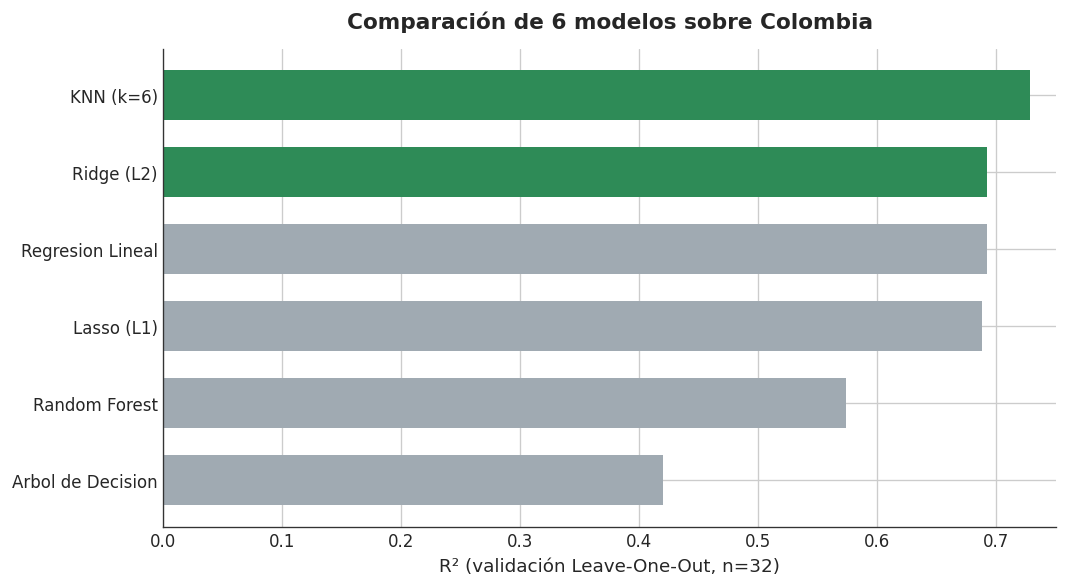

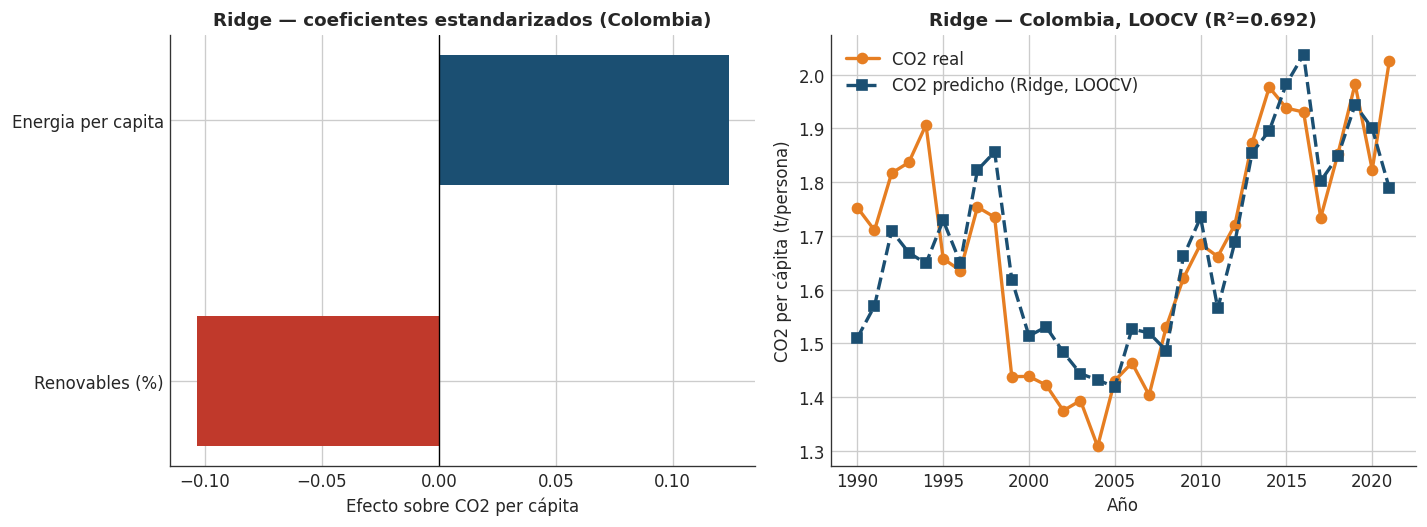

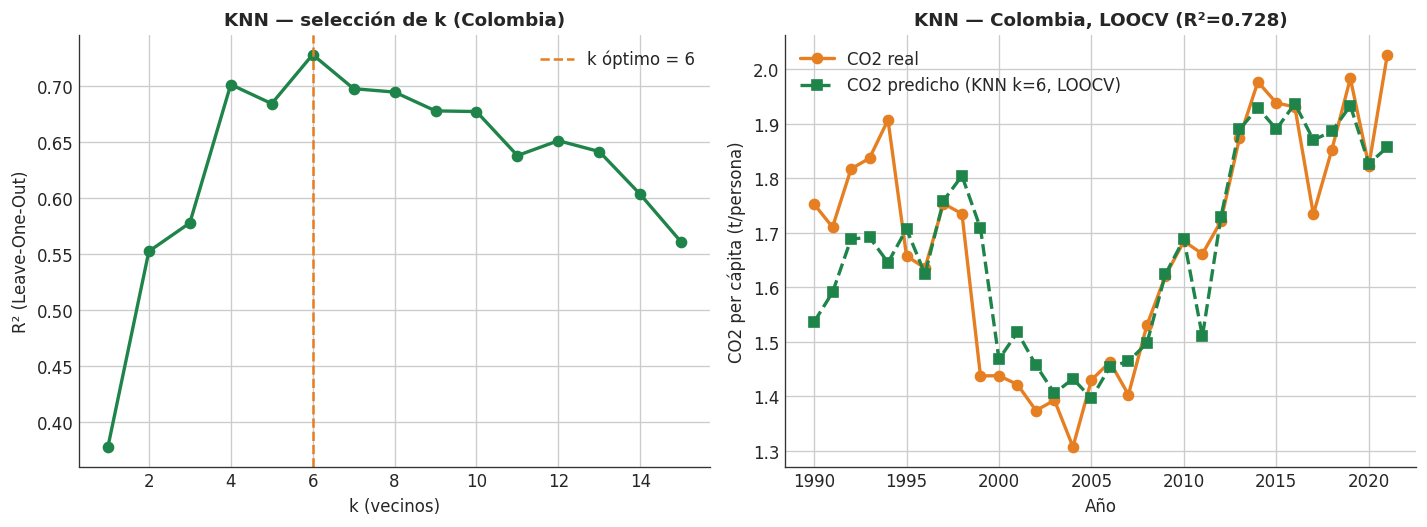

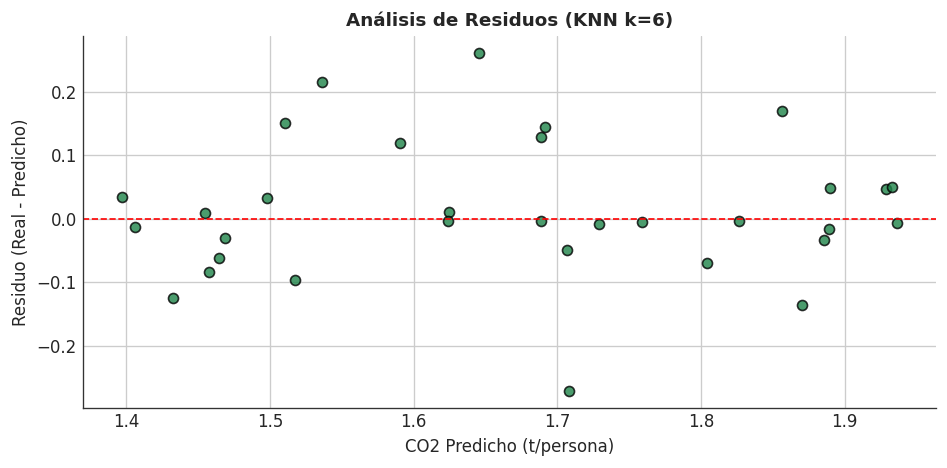

In [ ]:


# SECCIÓN 1: CONFIGURACIÓN E IMPORTACIÓN DE LIBRERÍAS
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import LeaveOneOut, cross_val_predict
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

from sklearn.linear_model import Ridge, LinearRegression, Lasso
from sklearn.neighbors import KNeighborsRegressor
from sklearn.ensemble import RandomForestRegressor
from sklearn.tree import DecisionTreeRegressor

from google.colab import files

plt.style.use('seaborn-v0_8-whitegrid')
plt.rcParams['font.sans-serif'] = 'DejaVu Sans'
plt.rcParams['axes.edgecolor'] = '#333333'
plt.rcParams['axes.linewidth'] = 0.8

print("Librerías cargadas exitosamente.")

# SECCIÓN 2: OBTENCIÓN, LIMPIEZA Y PRE-PROCESAMIENTO DE DATOS

# Repositorios (GitHub)
url_co2 = "https://raw.githubusercontent.com/owid/co2-data/master/owid-co2-data.csv"
url_energy = "https://raw.githubusercontent.com/owid/energy-data/master/owid-energy-data.csv"

print("Cargando datasets...")
df_co2_raw = pd.read_csv(url_co2)
df_energy_raw = pd.read_csv(url_energy)

# Colombia (1990-2021)
col_co2 = df_co2_raw[(df_co2_raw['country'] == 'Colombia') & (df_co2_raw['year'].between(1990, 2021))].copy()
col_energy = df_energy_raw[(df_energy_raw['country'] == 'Colombia') & (df_energy_raw['year'].between(1990, 2021))].copy()

# Variables importantes
col_co2 = col_co2[['year', 'co2', 'population']].rename(columns={'co2': 'CO2_Mt'})
col_energy = col_energy[['year', 'renewables_share_elec', 'primary_energy_consumption']].rename(
    columns={'renewables_share_elec': 'Renewables_pct', 'primary_energy_consumption': 'Energy_TWh'}
)

# Tablas por año (Merge)
df_colombia = pd.merge(col_co2, col_energy, on='year')

# Cálculo de variables per cápita
df_colombia['CO2_per_capita'] = (df_colombia['CO2_Mt'] * 1e6) / df_colombia['population']
df_colombia['Energy_per_capita'] = (df_colombia['Energy_TWh'] * 1e9) / df_colombia['population']
df_colombia.rename(columns={'year': 'Year'}, inplace=True)

# Tabla analitica
df_clean = df_colombia[['Year', 'CO2_Mt', 'CO2_per_capita', 'Renewables_pct', 'Energy_per_capita', 'population']].copy()

print("\n--- DATASET LIMPIO Y PROCESADO (Primeras 5 filas) ---")
print(df_clean.head())

# Exportación a Excel y descarga
excel_filename = "datos_limpios_colombia_1990_2021.xlsx"
df_clean.to_excel(excel_filename, index=False)
print(f"\nBase limpia guardada como '{excel_filename}'. Descargando...")
files.download(excel_filename)


# SECCIÓN 3: ESTADÍSTICA DESCRIPTIVA Y DISTRIBUCIONES

vars_cols = ['CO2_Mt', 'CO2_per_capita', 'Renewables_pct', 'Energy_per_capita']

def get_full_stats(df, columns):
    stats = []
    for col in columns:
        s = df[col]
        stats.append({
            'Variable': col,
            'Media': s.mean(),
            'Mediana': s.median(),
            'Moda*': s.round().mode()[0],
            'Desv. Est.': s.std(),
            'Asimetría (Skew)': s.skew(),
            'Mínimo': s.min(),
            'Máximo': s.max()
        })
    return pd.DataFrame(stats)

print("\n--- ESTADÍSTICA DESCRIPTIVA COMPLETA (COLOMBIA 1990-2021) ---")
print(get_full_stats(df_clean, vars_cols).round(2).to_string(index=False))

# Matriz de Correlación de Pearson completa
fig, ax = plt.subplots(figsize=(6, 4.5), dpi=120)
corr = df_clean[vars_cols].corr()
sns.heatmap(corr, annot=True, cmap='Blues', fmt='.3f', ax=ax, cbar=False)
ax.set_title('Matriz de Correlación de Pearson', fontsize=11, fontweight='bold', pad=10)
plt.tight_layout()
plt.show()


# SECCIÓN 4: ANÁLISIS EXPLORATORIO DE DATOS (EDA) - GRÁFICOS DE LA PRESENTACIÓN

# [Diapositiva 7]
fig, ax = plt.subplots(figsize=(10, 4.5), dpi=120)
ax.plot(df_clean['Year'], df_clean['CO2_Mt'], marker='o', color='#E67E22', linewidth=2.5, markersize=5)
ax.fill_between(df_clean['Year'], df_clean['CO2_Mt'], color='#E67E22', alpha=0.08)
ax.set_title('Emisiones de CO2 en Colombia · 56.9 Mt (1990) -> 103.7 Mt (2021)', fontsize=13, pad=12, fontweight='bold')
ax.set_ylabel('CO2 (Mt)', fontsize=11)
ax.set_xlabel('Año', fontsize=11)
ax.set_ylim(0, 110)
sns.despine()
plt.tight_layout()
plt.show()

# [Diapositiva 8]
fig, ax = plt.subplots(figsize=(10, 4.5), dpi=120)
ax.plot(df_clean['Year'], df_clean['Renewables_pct'], marker='o', color='#1E8449', linewidth=2.5, markersize=5)
ax.fill_between(df_clean['Year'], df_clean['Renewables_pct'], color='#1E8449', alpha=0.08)
ax.set_title('Electricidad renovable en Colombia · 72.6% (1990) -> 75.1% (2021)', fontsize=13, pad=12, fontweight='bold')
ax.set_ylabel('Electricidad renovable (%)', fontsize=11)
ax.set_xlabel('Año', fontsize=11)
ax.set_ylim(0, 100)
sns.despine()
plt.tight_layout()
plt.show()

# [Diapositiva 9]
fig, ax = plt.subplots(figsize=(7.5, 5.5), dpi=120)
r_ren = np.corrcoef(df_clean['Renewables_pct'], df_clean['CO2_per_capita'])[0, 1]
scatter = ax.scatter(df_clean['Renewables_pct'], df_clean['CO2_per_capita'], c=df_clean['Year'], cmap='YlGn', edgecolors='black', s=80, alpha=0.9)
cbar = plt.colorbar(scatter, ax=ax)
cbar.set_label('Año', fontsize=11)

m, b = np.polyfit(df_clean['Renewables_pct'], df_clean['CO2_per_capita'], 1)
x_vals = np.linspace(df_clean['Renewables_pct'].min(), df_clean['Renewables_pct'].max(), 100)
ax.plot(x_vals, m*x_vals + b, linestyle='--', color='gray', linewidth=1.5)

ax.set_title(f'Colombia 1990-2021 · r = {r_ren:.3f} (per cápita)', fontsize=12, fontweight='bold')
ax.set_xlabel('Electricidad renovable (%)', fontsize=11)
ax.set_ylabel('CO2 per cápita (t/persona)', fontsize=11)
sns.despine()
plt.tight_layout()
plt.show()

# [Diapositiva 10]
fig, ax = plt.subplots(figsize=(7.5, 5.5), dpi=120)
r_eng = np.corrcoef(df_clean['Energy_per_capita'], df_clean['CO2_per_capita'])[0, 1]
scatter = ax.scatter(df_clean['Energy_per_capita'], df_clean['CO2_per_capita'], c=df_clean['Year'], cmap='YlOrBr', edgecolors='black', s=80, alpha=0.9)
cbar = plt.colorbar(scatter, ax=ax)
cbar.set_label('Año', fontsize=11)

m, b = np.polyfit(df_clean['Energy_per_capita'], df_clean['CO2_per_capita'], 1)
x_vals = np.linspace(df_clean['Energy_per_capita'].min(), df_clean['Energy_per_capita'].max(), 100)
ax.plot(x_vals, m*x_vals + b, linestyle='--', color='gray', linewidth=1.5)

ax.set_title(f'Colombia 1990-2021 · r = {r_eng:.3f} (per cápita)', fontsize=12, fontweight='bold')
ax.set_xlabel('Energía per cápita (kWh/persona)', fontsize=11)
ax.set_ylabel('CO2 per cápita (t/persona)', fontsize=11)
sns.despine()
plt.tight_layout()
plt.show()


# SECCIÓN 5: COMPARACIÓN DE MODELOS DE MACHINE LEARNING (LOOCV)

X = df_clean[['Renewables_pct', 'Energy_per_capita']]
y = df_clean['CO2_per_capita']

loocv = LeaveOneOut()

models = {
    'Ridge (L2)': Pipeline([('scaler', StandardScaler()), ('model', Ridge(alpha=1.0))]),
    'Regresion Lineal': Pipeline([('scaler', StandardScaler()), ('model', LinearRegression())]),
    'Lasso (L1)': Pipeline([('scaler', StandardScaler()), ('model', Lasso(alpha=0.01))]),
    'KNN (k=6)': Pipeline([('scaler', StandardScaler()), ('model', KNeighborsRegressor(n_neighbors=6))]),
    'Random Forest': Pipeline([('scaler', StandardScaler()), ('model', RandomForestRegressor(n_estimators=100, random_state=42))]),
    'Arbol de Decision': DecisionTreeRegressor(random_state=42)
}

eval_list = []

for name, model in models.items():
    y_preds = cross_val_predict(model, X, y, cv=loocv)
    r2 = r2_score(y, y_preds)
    rmse = np.sqrt(mean_squared_error(y, y_preds))
    mae = mean_absolute_error(y, y_preds)
    eval_list.append({'Modelo': name, 'R² (LOOCV)': r2, 'RMSE': rmse, 'MAE': mae})

# Orden ascendente para la gráfica horizontal
df_eval = pd.DataFrame(eval_list).sort_values('R² (LOOCV)', ascending=True)

print("\n--- EVALUACIÓN COMPLETA DE LOS 6 MODELOS ---")
print(df_eval.sort_values('R² (LOOCV)', ascending=False).to_string(index=False))

# Gráfico de barras
fig, ax = plt.subplots(figsize=(9, 5), dpi=120)
colors = ['#2E8B57' if name in ['Ridge (L2)', 'KNN (k=6)'] else '#A0AAB2' for name in df_eval['Modelo']]
ax.barh(df_eval['Modelo'], df_eval['R² (LOOCV)'], color=colors, height=0.65)

ax.set_title('Comparación de 6 modelos sobre Colombia', fontsize=13, pad=12, fontweight='bold')
ax.set_xlabel('R² (validación Leave-One-Out, n=32)', fontsize=11)
ax.set_xlim(0, 0.75)
sns.despine()
plt.tight_layout()
plt.show()

# SECCIÓN 6: MODELOS SELECCIONADOS EN DETALLE (RIDGE Y KNN)

# RIDGE REGRESSION
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)
ridge_model = Ridge(alpha=1.0)
ridge_model.fit(X_scaled, y)

y_pred_ridge = cross_val_predict(Pipeline([('scaler', StandardScaler()), ('model', Ridge(alpha=1.0))]), X, y, cv=loocv)
r2_ridge = r2_score(y, y_pred_ridge)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4.5), dpi=120)

# Coeficientes
ax1.barh(['Renovables (%)', 'Energia per capita'], ridge_model.coef_, color=['#C0392B', '#1B4F72'], height=0.5)
ax1.axvline(0, color='black', linewidth=0.8)
ax1.set_title('Ridge — coeficientes estandarizados (Colombia)', fontsize=11, fontweight='bold')
ax1.set_xlabel('Efecto sobre CO2 per cápita', fontsize=10)

# Predicción vs Real
ax2.plot(df_clean['Year'], y, marker='o', color='#E67E22', label='CO2 real', linewidth=2)
ax2.plot(df_clean['Year'], y_pred_ridge, marker='s', color='#1B4F72', linestyle='--', label='CO2 predicho (Ridge, LOOCV)', linewidth=2)
ax2.set_title(f'Ridge — Colombia, LOOCV (R²={r2_ridge:.3f})', fontsize=11, fontweight='bold')
ax2.set_xlabel('Año', fontsize=10)
ax2.set_ylabel('CO2 per cápita (t/persona)', fontsize=10)
ax2.legend()

sns.despine()
plt.tight_layout()
plt.show()

# KNN (K-NEAREST NEIGHBORS)
k_range = range(1, 16)
k_scores = []

for k in k_range:
    knn_pipe = Pipeline([('scaler', StandardScaler()), ('model', KNeighborsRegressor(n_neighbors=k))])
    preds = cross_val_predict(knn_pipe, X, y, cv=loocv)
    k_scores.append(r2_score(y, preds))

k_optimal = k_range[np.argmax(k_scores)]

knn_opt_pipe = Pipeline([('scaler', StandardScaler()), ('model', KNeighborsRegressor(n_neighbors=k_optimal))])
y_pred_knn = cross_val_predict(knn_opt_pipe, X, y, cv=loocv)
r2_knn = r2_score(y, y_pred_knn)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4.5), dpi=120)

# Selección de K
ax1.plot(k_range, k_scores, marker='o', color='#1E8449', linewidth=2)
ax1.axvline(k_optimal, color='#E67E22', linestyle='--', label=f'k óptimo = {k_optimal}')
ax1.set_title('KNN — selección de k (Colombia)', fontsize=11, fontweight='bold')
ax1.set_xlabel('k (vecinos)', fontsize=10)
ax1.set_ylabel('R² (Leave-One-Out)', fontsize=10)
ax1.legend()

# Predicción vs Real
ax2.plot(df_clean['Year'], y, marker='o', color='#E67E22', label='CO2 real', linewidth=2)
ax2.plot(df_clean['Year'], y_pred_knn, marker='s', color='#1E8449', linestyle='--', label=f'CO2 predicho (KNN k={k_optimal}, LOOCV)', linewidth=2)
ax2.set_title(f'KNN — Colombia, LOOCV (R²={r2_knn:.3f})', fontsize=11, fontweight='bold')
ax2.set_xlabel('Año', fontsize=10)
ax2.set_ylabel('CO2 per cápita (t/persona)', fontsize=10)
ax2.legend()

sns.despine()
plt.tight_layout()
plt.show()


# SECCIÓN 7: ANÁLISIS DE RESIDUOS (MEJOR MODELO - KNN k=6)
residuals = y - y_pred_knn

fig, ax = plt.subplots(figsize=(8, 4), dpi=120)
ax.scatter(y_pred_knn, residuals, color='#1E8449', alpha=0.8, edgecolors='black')
ax.axhline(0, color='red', linestyle='--', linewidth=1)
ax.set_title('Análisis de Residuos (KNN k=6)', fontsize=11, fontweight='bold')
ax.set_xlabel('CO2 Predicho (t/persona)', fontsize=10)
ax.set_ylabel('Residuo (Real - Predicho)', fontsize=10)
sns.despine()
plt.tight_layout()
plt.show()